### Individual Homework

#### Enter your name here:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Analysis of movies IMDB dataset**

We will look at a ***subset*** sample of movies, taken from the [Kaggle IMDB 5000 movie dataset](https://www.kaggle.com/carolzhangdc/imdb-5000-movie-dataset)

In [2]:
movies = pd.read_csv('../Data/movies.csv')
movies

,title,genre,director,year,duration,gross,budget,cast_facebook_likes,votes,reviews,rating
0,Avatar,Action,James Cameron,2009,178,760505847,237000000,4834,886204,3777,7.9
1,Titanic,Drama,James Cameron,1997,194,658672302,200000000,45223,793059,2843,7.7
2,Jurassic World,Action,Colin Trevorrow,2015,124,652177271,150000000,8458,418214,1934,7.0
3,The Avengers,Action,Joss Whedon,2012,173,623279547,220000000,87697,995415,2425,8.1
4,The Dark Knight,Action,Christopher Nolan,2008,152,533316061,185000000,57802,1676169,5312,9.0
...,...,...,...,...,...,...,...,...,...,...,...
2956,Locker 13,Thriller,Bruce Dellis,2014,95,2468,300000,2048,241,15,4.8
2957,The Ghastly Love of Johnny X,Comedy,Paul Bunnell,2012,106,2436,2000000,1611,344,113,5.7
2958,Detention of the Dead,Comedy,Alex Craig Mann,2012,87,1332,500000,2251,2038,49,4.6
2959,The Trials of Darryl Hunt,Crime,Ricki Stern,2006,106,1111,200000,2,771,21,7.7


Besides the obvious variables of `title`, `genre`, `director`, `year`, and `duration`, the rest of the variables are as follows:

-   `gross` : The gross earnings in the US box office, not adjusted for inflation
-   `budget`: The movie's budget
-   `cast_facebook_likes`: the number of facebook likes cast memebrs received
-   `votes`: the number of people who voted for (or rated) the movie in IMDB
-   `reviews`: the number of reviews for that movie
-   `rating`: IMDB average rating

**Produce a table with the count of movies by genre, ranked in descending order**


In [3]:
(
    movies.groupby("genre")
    .agg(movies_count = ("genre", "count"))
    .reset_index()
    .sort_values("movies_count", ascending=False)
)

,genre,movies_count
4,Comedy,848
0,Action,738
7,Drama,498
1,Adventure,288
5,Crime,202
3,Biography,135
10,Horror,131
2,Animation,35
9,Fantasy,28
6,Documentary,25


**Produce a table with the average gross earning and budget (`gross` and `budget`) by genre. Calculate a variable `return_on_budget` which shows how many \$ did a movie make at the box office for each \$ of its budget. Ranked genres by this `return_on_budget` in descending order**

In [4]:
(
    movies.groupby("genre")
    .agg(
        avg_gross=("gross", "mean"),
        avg_budget=("budget", "mean")
    )
    .assign(return_on_budget=lambda x: x["avg_gross"] / x["avg_budget"])
    .sort_values("return_on_budget", ascending=False)
    .reset_index()
)


,genre,avg_gross,avg_budget,return_on_budget
0,Musical,9.208400e+07,3.189500e+06,28.870983
1,Family,1.491605e+08,1.483333e+07,10.055763
2,Western,2.082188e+07,3.465000e+06,6.009202
3,Documentary,1.735397e+07,5.887852e+06,2.947420
4,Horror,3.771374e+07,1.350492e+07,2.792593
5,Fantasy,4.240884e+07,1.758214e+07,2.412040
6,Comedy,4.263055e+07,2.444632e+07,1.743843
7,Mystery,6.753302e+07,3.921875e+07,1.721958
8,Animation,9.843379e+07,6.170143e+07,1.595324
9,Biography,4.520181e+07,2.854370e+07,1.583600


**Produce a table that shows the top 15 directors who have created the highest gross revenue in the box office. Don't just show the total gross amount, but also the mean, median, and standard deviation per director**

In [25]:
(
    movies.groupby('director')
    .agg(total_gross_amount= ("gross","sum"), mean_gross_amount=("gross", "mean"), 
         median_gross_amount=("gross", "median"), std_gross_amount=("gross", "std"))
    .sort_values("total_gross_amount", ascending=False)
    .head(15)
    .reset_index()
)

,director,total_gross_amount,mean_gross_amount,median_gross_amount,std_gross_amount
0,Steven Spielberg,4014061704,1.745244e+08,164435221.0,1.014211e+08
1,Michael Bay,2231242537,1.716340e+08,138396624.0,1.271616e+08
2,Tim Burton,2071275480,1.294547e+08,76519172.0,1.087269e+08
3,Sam Raimi,2014600898,2.014601e+08,234903076.0,1.621266e+08
4,James Cameron,1909725910,3.182877e+08,175562880.5,3.091713e+08
5,Christopher Nolan,1813227576,2.266534e+08,196667606.5,1.872241e+08
6,George Lucas,1741418480,3.482837e+08,380262555.0,1.461939e+08
7,Robert Zemeckis,1619309108,1.245622e+08,100853835.0,9.130028e+07
8,Clint Eastwood,1378321100,7.254322e+07,46700000.0,7.548741e+07
9,Francis Lawrence,1358501971,2.717004e+08,281666058.0,1.354370e+08


**Produce a table that describes how ratings are distributed by genre. We don't want just the mean, but also, min, max, median, SD and some kind of a histogram or density graph that visually shows how ratings are distributed.**

In [9]:
rating_distribution_by_genre = (
    movies.groupby("genre")
    .agg(mean_rating=("rating","mean"),min_rating=("rating","min"),
         max_rating=("rating","max"),median_rating=("rating","median"),std_rating=("rating","std"))
    .sort_values("mean_rating", ascending=False)
    .reset_index()
)
rating_distribution_by_genre

,genre,mean_rating,min_rating,max_rating,median_rating,std_rating
0,Biography,7.114074,4.5,8.9,7.20,0.759827
1,Crime,6.915347,4.8,9.3,6.90,0.849356
2,Mystery,6.856250,4.6,8.5,6.90,0.881641
3,Musical,6.750000,6.3,7.2,6.75,0.636396
4,Drama,6.731526,2.1,8.8,6.80,0.916993
5,Documentary,6.660000,1.6,8.5,7.40,1.766588
6,Sci-Fi,6.657143,5.0,8.2,6.40,1.093705
7,Animation,6.651429,4.5,8.0,6.90,0.968131
8,Romance,6.650000,6.2,7.1,6.65,0.636396
9,Adventure,6.506597,2.3,8.6,6.60,1.093881


C:\Users\yashk\AppData\Local\Temp\ipykernel_38508\678636094.py:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=movies, x="rating", hue="genre", common_norm=False, fill=True, alpha=0.3)


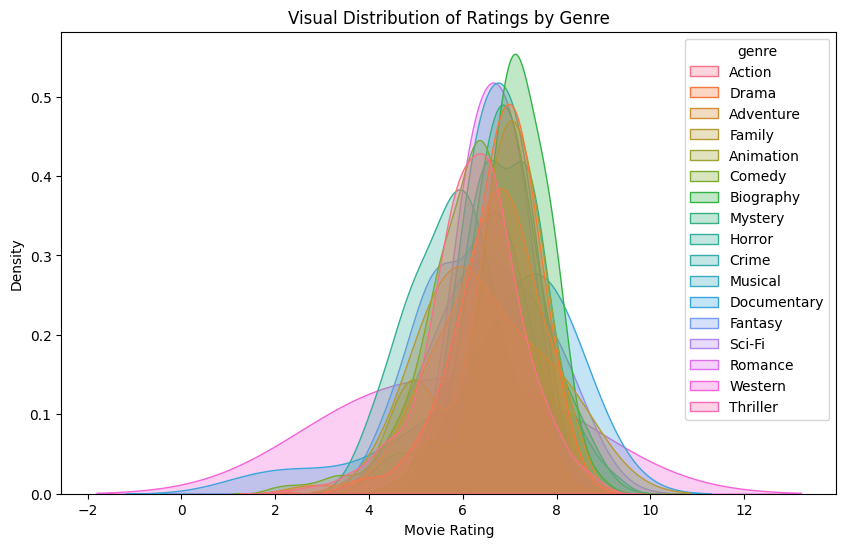

In [10]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=movies, x="rating", hue="genre", common_norm=False, fill=True, alpha=0.3)
plt.title("Visual Distribution of Ratings by Genre")
plt.xlabel("Movie Rating")
plt.ylabel("Density")
plt.show()


C:\Users\yashk\AppData\Local\Temp\ipykernel_38508\1995495583.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=movies, x="rating", y="genre", palette="viridis")


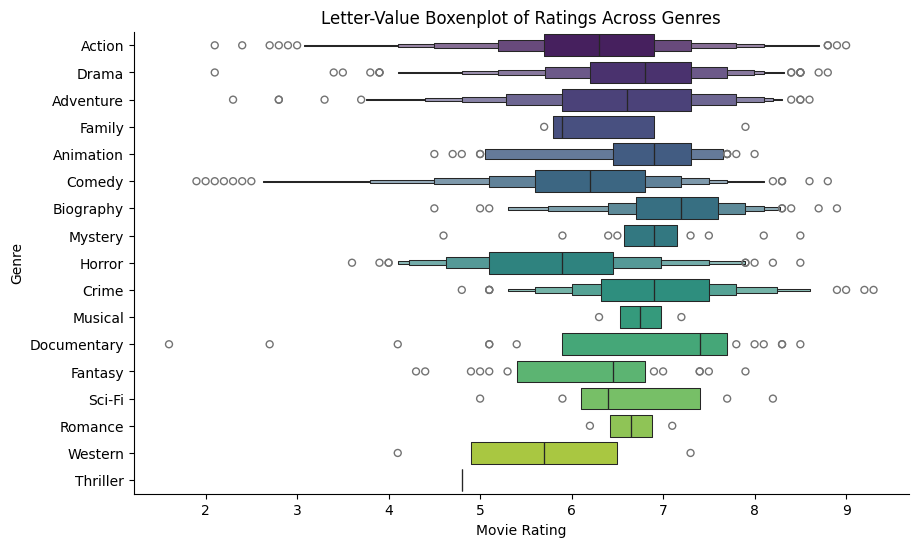

In [11]:
plt.figure(figsize=(10, 6))

# Boxenplots draw progressively smaller boxes to map variance out to the extremes
sns.boxenplot(data=movies, x="rating", y="genre", palette="viridis")

plt.title("Letter-Value Boxenplot of Ratings Across Genres")
plt.xlabel("Movie Rating")
plt.ylabel("Genre")
sns.despine()
plt.show()

**Challenge - Produce a table of your own choosing, something you think is important/interesting to have data for, justify your result by writting a 2 sentence explanation/interpretation of the result.**

503.3053022627491


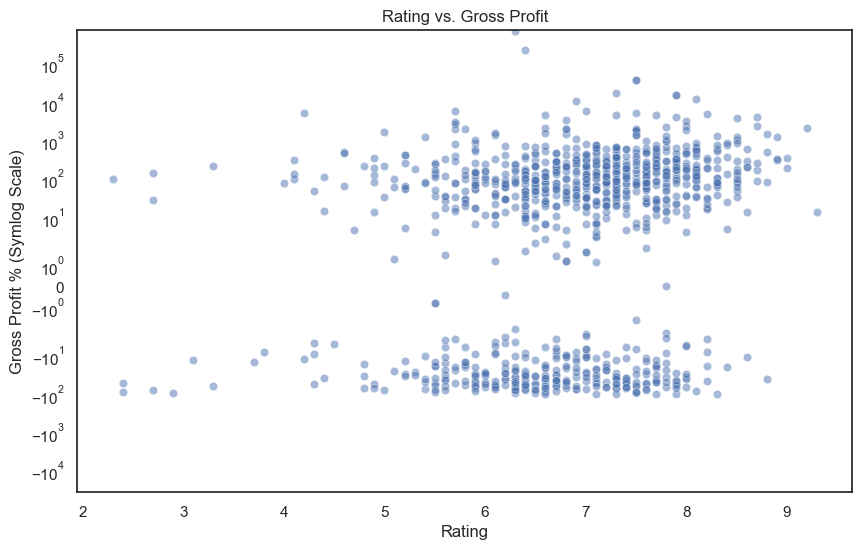

In [34]:
mean_reviews = movies["reviews"].mean()
print(mean_reviews)
gross_profit_movie = (
    movies.assign(gross_profit = (movies["gross"] - movies["budget"])*100/ movies["budget"])
    .sort_values("rating", ascending=False)
    .sort_values("reviews", ascending=False)
    .query("reviews > reviews.mean()")
)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=gross_profit_movie, x='rating', y='gross_profit', alpha=0.5)

# Apply a symmetrical log scale to the y-axis
plt.yscale('symlog')
plt.ylabel('Gross Profit % (Symlog Scale)')
plt.xlabel('Rating')
plt.title('Rating vs. Gross Profit')
plt.show()

#### Use visualisation to answer the following questions

**Examine the relationship between `gross` and `cast_facebook_likes`. Produce a scatterplot and write one sentence discussing whether the number of facebook likes that the cast has received is likely to be a good predictor of how much money a movie will make at the box office. What variable are you going to map to the Y- and X- axes?**

**Examine the relationship between `gross` and `budget`. Produce a scatterplot and write one sentence discussing whether budget is likely to be a good predictor of how much money a movie will make at the box office.**

**Examine the relationship between `gross` and `rating`. Produce a scatterplot, faceted by `genre` and discuss whether IMDB ratings are likely to be a good predictor of how much money a movie will make at the box office. Is there anything strange in this dataset?**

**Challenge - Produce a visualisation of your choosing, something you think is important to explore/investigate visually. Do make it a comprehensive graph and not a single histogram or density plot. Make it publication ready, label your axes, give it a title, choose colouring options, appropirately formatted text etc.**

### Deliverables

Poduce a clean, stand-alone notebook (or HTML export) with:

All tables/plots properly labeled

Brief interpretations where requested

Upload final HTML/Notebook.